# 5장 Layout Out Pages

## 5.1 The Layout Tree

지금까지는 `Layout` 클래스가 HTML DOM Tree를 순회하며 화면에 그릴 모든 텍스트의 좌표를 계산했다.

하지만 실제로는 요소마다 레이아웃 방식(블록, 인라인, 플렉스 등)이 다르기 때문에, 레이아웃 트리를 분리한다.



지금까지(Chapter 4)는 단일 `Layout` 클래스가 HTML 트리(DOM)를 순회하며 화면에 그릴 모든 텍스트의 좌표를 계산했습니다. 
하지만 실제 브라우저는 요소마다 레이아웃 방식(블록, 인라인, 플렉스 등)이 다르기 때문에, 이를 하나의 클래스에서 모두 처리하면 코드가 지나치게 복잡해집니다.

이를 해결하기 위해 5장에서는 **HTML 트리(DOM Tree)와 레이아웃 트리(Layout Tree)를 분리**합니다. 

#### 1. 레이아웃 트리의 핵심 개념
- HTML 트리의 노드가 "문서의 구조(의미)"를 나타낸다면, 레이아웃 트리의 노드는 화면에 그려지는 **"시각적인 박스(Box)"** 를 나타냅니다.
- 각 레이아웃 노드는 자신만의 `x`, `y`, `width`, `height`를 가집니다.
- 각 노드는 자신의 자식 노드들에게 "너비(width)"를 알려주고, 자식들은 레이아웃을 마친 뒤 자신의 "높이(height)"를 부모에게 반환하는 재귀적인 구조를 가집니다.

#### 2. 주요 클래스 리팩토링
- **`DocumentLayout`**: 레이아웃 트리의 최상위 루트 노드입니다. 브라우저 창 전체를 나타냅니다.
- **`BlockLayout`**: `<p>`, `<h1>`, `<div>` 등 위에서 아래로 쌓이는 **블록 요소**를 담당하는 레이아웃 노드입니다. 이전 부모(`parent`)와 이전 형제(`previous`) 노드의 참조를 가지고 있어 자신의 Y 좌표를 계산하는 데 사용합니다.

#### 3. 변경된 렌더링 흐름
이전에는 `Layout(nodes).display_list`로 한 번에 처리했지만, 이제는 각 레이아웃 클래스에 있는 `layout()` 메서드를 호출하여 계층적으로 레이아웃을 계산합니다.
```python
# browser.py 변경점 요약
self.document = DocumentLayout(self.nodes)
self.document.layout()
self.display_list = self.document.display_list
```

## 5.2 Block and Inline Layout

HTML 요소는 화면에 배치되는 방식에 따라 크게 **블록(Block)** 요소와 **인라인(Inline)** 요소로 나눌 수 있습니다.

#### 블록 요소 (Block Elements)
- `<p>`, `<div>`, `<h1>` 등
- 부모의 너비를 가득 채우며, 기본적으로 **위에서 아래로(수직으로)** 쌓입니다.
- 즉, 이전 형제 노드(previous sibling)의 아래쪽에 배치됩니다.

#### 인라인 요소 (Inline Elements)
- `<b>`, `<i>`, 일반 텍스트(`Text` 노드) 등
- 텍스트처럼 **왼쪽에서 오른쪽으로(수평으로)** 흐르며, 공간이 부족하면 줄바꿈(wrap)이 일어납니다.

#### `layout_mode` 결정 알고리즘
어떤 요소가 블록 레이아웃을 따를지, 인라인 레이아웃을 따를지는 자식 노드의 구성에 따라 결정됩니다. `layout.py`에 추가된 `layout_mode` 함수가 이 역할을 합니다.

1. **텍스트 노드인 경우**: 항상 "inline"
2. **자식 중 하나라도 블록 요소가 있는 경우**: 이 노드도 "block" 레이아웃을 사용해야 함 (블록 요소가 섞여 있으면 전체를 블록 컨텍스트로 처리)
3. **자식이 모두 인라인 요소(또는 텍스트)인 경우**: "inline" 레이아웃 사용
4. **자식이 없는 경우**: 기본적으로 "block"

#### BlockLayout의 `layout` 동작 분기
`BlockLayout`은 `layout_mode`의 결과에 따라 다르게 동작합니다.
- `mode == "block"`: 자식 요소들도 별도의 블록으로 간주하여 재귀적으로 `BlockLayout` 객체를 생성하고 레이아웃 트리에 추가합니다.
- `mode == "inline"`: 자식 요소들이 인라인 컨텍스트를 구성하므로, 이전 챕터에서 사용하던 방식(`recurse`, `word`, `flush` 등)을 사용하여 텍스트 라인 브레이킹 및 인라인 배치를 수행합니다. (현재 코드는 임시로 `BlockLayout` 내부에 `recurse` 로직을 남겨둔 상태입니다.)

### `print_tree`를 활용한 DOM 트리 vs 레이아웃 트리 비교
`html.py`에 정의된 `print_tree` 함수를 사용하면 트리의 구조를 직관적으로 확인할 수 있습니다.
- HTML 트리는 `Element`와 `Text` 노드로 구성됩니다.
- 레이아웃 트리는 `DocumentLayout`을 루트로 하고, 그 아래에 `BlockLayout` (또는 나중에 추가될 `InlineLayout`) 노드들로 구성됩니다.

아래 코드를 실행하여 두 트리가 어떻게 다르게 구성되는지 확인해 보세요!

In [1]:
from browser.html import HTMLParser, print_tree
from browser.layout import DocumentLayout

html_content = """
<html>
  <body>
    <h1>Hello, Layout Tree!</h1>
    <p>This is a <b>test</b> of the layout tree.</p>
  </body>
</html>
"""

print("=== HTML DOM Tree ===")
nodes = HTMLParser(html_content).parse()
print_tree(nodes)

print("\n=== Layout Tree ===")
document = DocumentLayout(nodes)
document.layout()
print_tree(document)


=== HTML DOM Tree ===
 <html>
   <body>
     <h1>
       'Hello, Layout Tree!'
     <p>
       'This is a '
       <b>
         'test'
       ' of the layout tree.'

=== Layout Tree ===
 DocumentLayout()
   BlockLayout(<html>)
     BlockLayout(<body>)
       BlockLayout(<h1>)
       BlockLayout(<p>)


## 5.3 Size and Position (크기와 위치)

레이아웃 트리의 핵심은 각 `BlockLayout` 요소가 자신만의 좌표(`x`, `y`)와 크기(`width`, `height`)를 계산하는 것입니다. 이 계산은 **위에서 아래로(Top-Down)** 흐르는 성질과 **아래에서 위로(Bottom-Up)** 흐르는 성질이 결합되어 이루어집니다.

### 1. Width와 위치 (Top-Down)
- **`x` 좌표**: 부모의 `x` 좌표를 그대로 상속받습니다.
- **`width`**: 부모가 제공하는 가용 너비(부모의 `width`)를 꽉 채우도록 설정됩니다.
- **`y` 좌표**: 부모의 `y`부터 시작하되, 이전 형제 노드(`previous`)가 있다면 그 형제 노드의 아래쪽(`previous.y + previous.height`)에서부터 시작합니다.
- **왜 먼저 계산될까요?** 텍스트를 몇 줄로 줄바꿈(Word Wrap)할지 결정하려면 상자의 너비(Width)를 먼저 확정해야 하기 때문입니다.

### 2. Height (Bottom-Up)
- 블록 요소의 높이는 고정되어 있지 않고, 내부의 자식 요소들이 얼마나 많은 공간을 차지하느냐에 따라 늘어납니다.
- 따라서 부모는 자식들(`self.children`)의 `layout()`을 모두 호출하여 배치를 끝낸 뒤에야 높이를 확정할 수 있습니다.
- **블록 모드인 경우**: 모든 자식들의 높이(`child.height`)를 합산하여 자신의 높이로 확정합니다.
- **인라인 모드인 경우**: 텍스트를 모두 줄바꿈하여 배치한 뒤의 최종 커서 위치(`self.cursor_y`)가 곧 텍스트 상자의 높이가 됩니다.

```python
# BlockLayout.layout() 내의 높이 계산 로직
if mode == "block":
    self.height = sum([child.height for child in self.children])
else:
    self.height = self.cursor_y
```

## 5.4 Painting (그리기 명령 분리)

5.2절과 5.3절을 거치면서 레이아웃 트리가 완성되었지만, 화면에 글자를 그리기 위한 `display_list`는 어떻게 수집해야 할지 모호한 상태였습니다. 5.4절에서는 **"레이아웃(위치/크기 계산)"**과 **"페인팅(화면에 그리기)"** 과정을 완벽하게 분리합니다.

### 1. `paint()` 메서드
각 레이아웃 클래스(`DocumentLayout`, `BlockLayout`)에 `paint()` 메서드가 추가됩니다.
- 이 메서드는 오직 자신(현재 노드)이 그려야 할 그리기 명령(`display_list` 요소)들만 배열로 반환합니다.

### 2. `paint_tree()` 재귀 함수
레이아웃 트리를 순회하며 모든 노드의 `paint()` 결과를 하나의 `display_list`로 모아주는 전역(Global) 함수입니다.
```python
def paint_tree(layout_object, display_list):
    display_list.extend(layout_object.paint())
    for child in layout_object.children:
        paint_tree(child, display_list)
```
- 레이아웃 노드의 종류에 상관없이 공통적으로 트리를 순회할 수 있도록 클래스 내부가 아닌, 외부에 별도의 모듈 레벨 함수로 정의합니다.

### 🌟 브라우저 렌더링 흐름의 최종 변화
이제 브라우저는 다음과 같이 두 단계로 명확히 나뉘어 동작합니다!
1. `document.layout()`: 전체 트리를 돌며 절대 좌표와 크기를 구합니다.
2. `paint_tree()`: 트리를 다시 돌며 화면에 그릴 요소들을 수집합니다.

아래 코드를 실행해서 `paint_tree`가 수집한 그리기 명령(`display_list`)을 확인해 보세요.

In [2]:
from browser.html import HTMLParser
from browser.layout import DocumentLayout, paint_tree

html_content = """
<html>
  <body>
    <h1>Separation of Concerns</h1>
    <p>Layout computes <b>size</b> and <b>position</b>.</p>
    <p>Painting collects <b>display lists</b>.</p>
  </body>
</html>
"""

nodes = HTMLParser(html_content).parse()
document = DocumentLayout(nodes)

# 1단계: 레이아웃 계산
document.layout()

# 2단계: 페인팅 명령 수집
display_list = []
paint_tree(document, display_list)

print(f"Total paint commands collected: {len(display_list)}\n")
for cmd in display_list:
    print(cmd)


Total paint commands collected: 14



## 5.5 Backgrounds (배경 그리기와 커맨드 패턴)

지금까지 브라우저의 `display_list`는 그저 `(x, y, word, font)` 형태의 단순한 튜플 묶음에 불과했습니다. 5.5절에서는 이 단순한 리스트를 **"스스로 그려질 줄 아는 커맨드(Command) 객체"** 들의 리스트로 발전시킵니다. 

이러한 객체지향적인 접근(커맨드 패턴)을 도입하면 두 가지 엄청난 장점이 생깁니다:
1. **다양한 그래픽 요소 추가 가능**: 글자(`DrawText`)뿐만 아니라 배경 사각형(`DrawRect`) 등 다양한 종류의 명령 객체를 동일한 인터페이스(`.execute()`)로 렌더링할 수 있습니다.
2. **렌더링 최적화(Culling)**: 각 그리기 명령 객체가 자신의 위(`top`)와 아래(`bottom`) 좌표를 알고 있기 때문에, **현재 스크롤 화면(Viewport)에서 벗어난 요소들은 아예 캔버스에 그리지 않고 건너뛰는(Culling)** 최적화가 가능해집니다.

### 주요 변경 사항
- **`DrawText` & `DrawRect` 클래스 도입**: `execute(scroll, canvas)` 인터페이스를 공통으로 가짐
- **`<pre>` 태그 배경**: `BlockLayout.paint()` 내부에서 태그가 `pre`일 경우 텍스트 뒤에 깔리는 회색 사각형(`DrawRect`)을 명령 리스트 맨 앞에 추가
- **화면 밖 렌더링 건너뛰기**: `Browser.draw()`에서 `cmd.top > self.scroll + HEIGHT` 이거나 `cmd.bottom < self.scroll` 인 경우 실행 안 함
- **스크롤 제한**: `Browser.scrolldown()` 시 `self.document.height`를 참조하여 문서 맨 밑바닥을 넘어서 스크롤이 내려가지 않도록 제한(`max_y`)

In [3]:
from browser.html import HTMLParser
from browser.layout import DocumentLayout, paint_tree
from browser.layout import DrawText, DrawRect # 5.5에서 추가된 커맨드 객체

html_content = """
<html>
  <body>
    <h1>Command Pattern</h1>
    <p>Using command objects allows us to draw more than just text!</p>
    <pre>
def hello():
    print("This block should have a gray background!")
    </pre>
  </body>
</html>
"""

nodes = HTMLParser(html_content).parse()
document = DocumentLayout(nodes)
document.layout()

display_list = []
paint_tree(document, display_list)

print(f"Total commands: {len(display_list)}\n")
for cmd in display_list:
    if isinstance(cmd, DrawRect):
        print(f"[Rect] Color: {cmd.color}, Bounds: ({cmd.left}, {cmd.top}) to ({cmd.right}, {cmd.bottom})")
    elif isinstance(cmd, DrawText):
        print(f"[Text] '{cmd.text}' at ({cmd.left}, {cmd.top})")


Total commands: 17

[Text] 'Command' at (316.0, 41.5)
[Text] 'Pattern' at (422.0, 41.5)
[Text] 'Using' at (13, 109.5)
[Text] 'command' at (56, 109.5)
[Text] 'objects' at (124, 109.5)
[Text] 'allows' at (174, 109.5)
[Text] 'us' at (220, 109.5)
[Text] 'to' at (239, 109.5)
[Text] 'draw' at (256, 109.5)
[Text] 'more' at (292, 109.5)
[Text] 'than' at (329, 109.5)
[Text] 'just' at (361, 109.5)
[Text] 'text!' at (389, 109.5)
[Rect] Color: gray, Bounds: (13, 146.25) to (787, 231.75)
[Text] 'def hello():' at (13, 149.5)
[Text] '    print("This block should have a gray background!")' at (13, 172.0)
[Text] '    ' at (13, 194.5)


### 🌟 결론 및 결과 화면 (스크린샷)

5장의 모든 레이아웃 로직(Block & Inline, Size & Position, Recursive Painting, Backgrounds)이 반영된 브라우저 엔진으로 `https://browser.engineering/` (브라우저 엔지니어링 홈페이지)를 직접 렌더링해 봅니다.

아래 셀을 실행하면 주피터 노트북 자체 기능(`display_tk_window`)을 통해 브라우저 창을 띄운 뒤, 스크린샷을 찍어 결과를 남기고 깔끔하게 종료합니다.

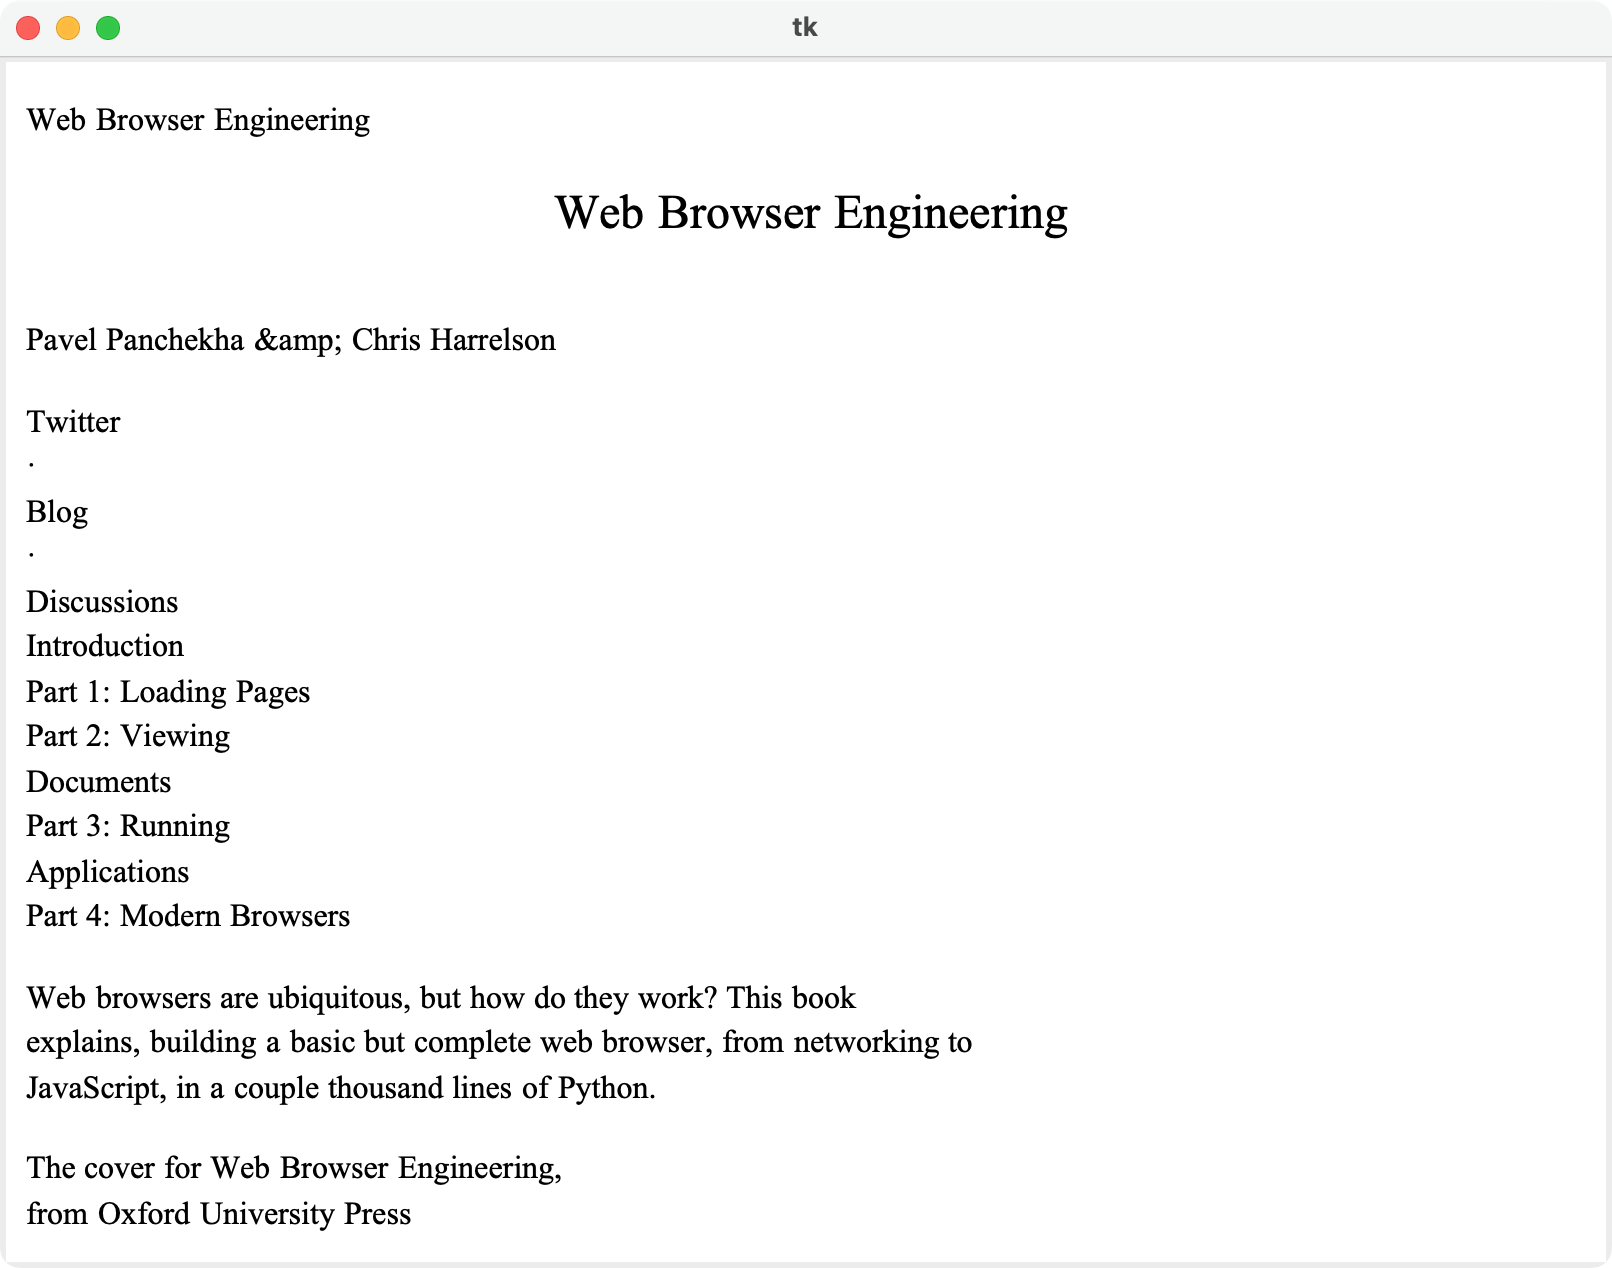

In [4]:
import tkinter
from browser.url import URL
from browser.browser import Browser
from browser.tk_capture import display_tk_window

# 브라우저 엔지니어링 홈페이지 URL 파싱
url = URL("https://browser.engineering/")

# 브라우저 인스턴스 생성 및 페이지 로드
browser = Browser()
browser.load(url)

# GUI 창 스크린샷 캡처 및 주피터 노트북 내장 출력 (출력 후 창 자동 종료)
display_tk_window(browser.window)


## 5.8 Exercises

#### 5-1 Links bar
At the top and bottom of the web version of each chapter of this book there is a gray bar naming the chapter and offering back and forward links. It is enclosed in a `<nav class="links">` tag. Have your browser give this links bar the light gray background a real browser would.

--- 생성된 그리기 커맨드 목록 ---
[Text] 'Chapter' at (272.5, 41.5)
[Text] '5:' at (354.5, 41.5)
[Text] 'Laying' at (379.5, 41.5)
[Text] 'Out' at (453.5, 41.5)
[Text] 'Pages' at (495.5, 41.5)
[Rect] Color: lightgray, Bounds: (13, 87.75) to (787, 110.25)
[Text] 'Previous' at (13, 91.5)
[Text] '|' at (73, 91.5)
[Text] 'Next' at (81, 91.5)
[Text] 'This' at (13, 132.0)
[Text] 'is' at (46, 132.0)
[Text] 'a' at (61, 132.0)
[Text] 'paragraph' at (73, 132.0)
[Text] 'below' at (141, 132.0)
[Text] 'the' at (185, 132.0)
[Text] 'links' at (209, 132.0)
[Text] 'bar.' at (245, 132.0)

--- 브라우저 렌더링 스크린샷 ---


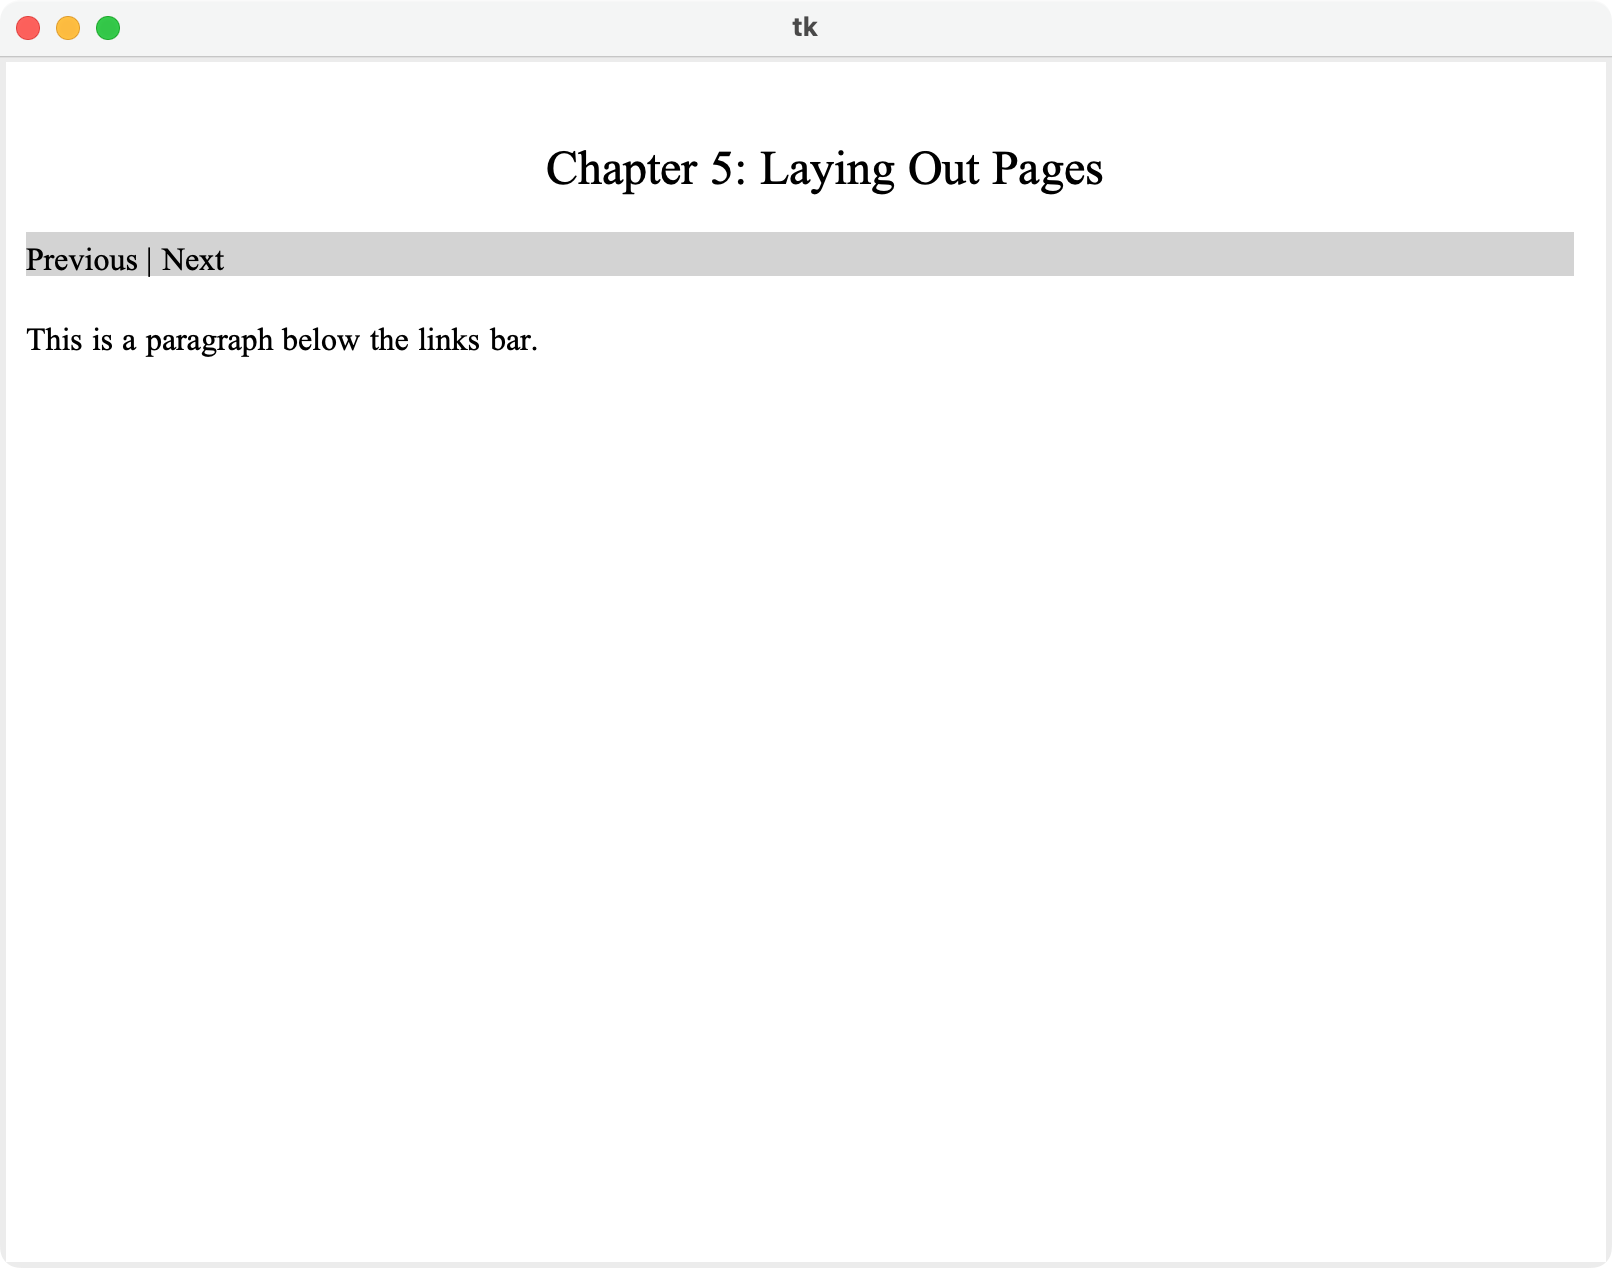

In [1]:
import tkinter
from browser.html import HTMLParser
from browser.layout import DocumentLayout, paint_tree, DrawRect, DrawText
from browser.browser import Browser
from browser.tk_capture import display_tk_window

# 테스트용 HTML: nav 태그에 class="links" 속성이 포함되어 있습니다.
html_content = """
<html>
  <body>
    <h1>Chapter 5: Laying Out Pages</h1>
    <nav class="links">
        Previous | Next
    </nav>
    <p>This is a paragraph below the links bar.</p>
  </body>
</html>
"""

# 1. HTML 파싱 및 레이아웃 트리 생성
nodes = HTMLParser(html_content).parse()
document = DocumentLayout(nodes)
document.layout()

# 2. 페인팅을 통해 display_list 커맨드 추출
display_list = []
paint_tree(document, display_list)

# 3. 터미널로 커맨드 검증 (lightgray 배경이 있는지 확인)
print("--- 생성된 그리기 커맨드 목록 ---")
for cmd in display_list:
    if isinstance(cmd, DrawRect):
        print(f"[Rect] Color: {cmd.color}, Bounds: ({cmd.left}, {cmd.top}) to ({cmd.right}, {cmd.bottom})")
    elif isinstance(cmd, DrawText):
        print(f"[Text] '{cmd.text}' at ({cmd.left}, {cmd.top})")
print("\n--- 브라우저 렌더링 스크린샷 ---")

# 4. 브라우저 창 띄워서 스크린샷 남기기
browser = Browser()
browser.nodes = nodes
browser.document = document
browser.display_list = display_list
browser.draw() # 수집된 display_list를 캔버스에 그리기

display_tk_window(browser.window)


#### 5-4 Table of contents
The web version of this book has a table of contents at the top of each chapter, enclosed in a `<nav id="toc">` tag, which contains a list of links. Add the text “Table of Contents”, with a gray background, above that list. Don’t modify the lexer or parser.

## Exercise 5-4: Table of contents 테스트

직접 구현한 5-4 연습문제 코드가 잘 동작하는지 확인하기 위한 테스트 셀입니다. `<nav id="toc">` 태그를 만나면 파싱된 트리에 "Table of Contents" 텍스트와 배경용 `div.table-of-contents-title` 노드가 성공적으로 끼워 넣어지는지, 그리고 기존 링크 목록들이 타이틀 글자와 겹치지 않고 잘 아래로 밀려나 렌더링되는지 터미널 출력과 스크린샷을 통해 확인합니다.

--- 생성된 그리기 커맨드 목록 ---
[Rect] Color: gray, Bounds: (13, 87.75) to (787, 110.25)

--- 브라우저 렌더링 스크린샷 ---


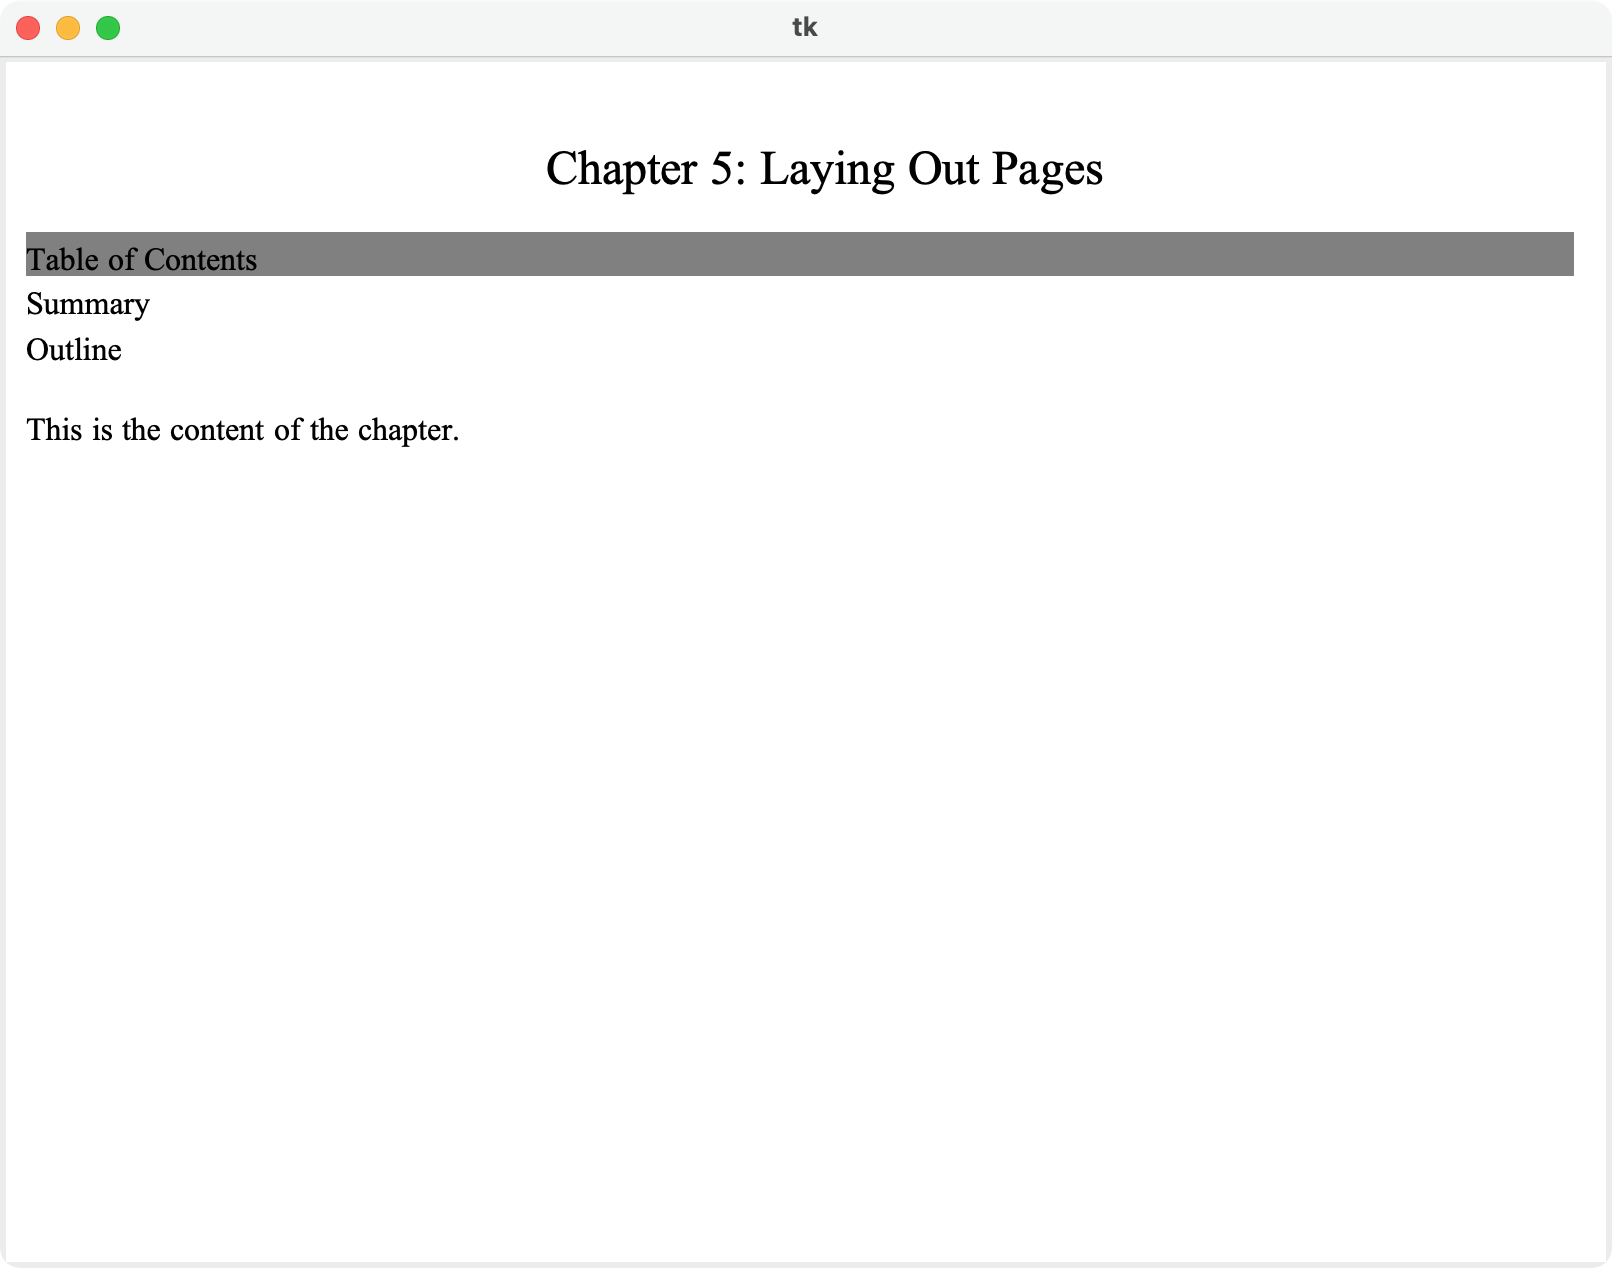

In [1]:
import tkinter
from browser.html import HTMLParser
from browser.layout import DocumentLayout, paint_tree, DrawRect, DrawText
from browser.browser import Browser
from browser.tk_capture import display_tk_window

# 테스트용 HTML: nav 태그에 id="toc" 속성이 포함되어 있습니다.
html_content = """
<html>
  <body>
    <h1>Chapter 5: Laying Out Pages</h1>
    <nav id="toc">
        <ul>
            <li><a href="#summary">Summary</a></li>
            <li><a href="#outline">Outline</a></li>
        </ul>
    </nav>
    <p>This is the content of the chapter.</p>
  </body>
</html>
"""

# 1. HTML 파싱 및 레이아웃 트리 생성
nodes = HTMLParser(html_content).parse()
document = DocumentLayout(nodes)
document.layout()

# 2. 페인팅을 통해 display_list 커맨드 추출
display_list = []
paint_tree(document, display_list)

# 3. 터미널 출력 확인 (gray 배경의 toc-title이 생성되었는지)
print("--- 생성된 그리기 커맨드 목록 ---")
for cmd in display_list:
    if isinstance(cmd, DrawRect):
        print(f"[Rect] Color: {cmd.color}, Bounds: ({cmd.left}, {cmd.top}) to ({cmd.right}, {cmd.bottom})")
    elif isinstance(cmd, DrawText) and "Table of Contents" in cmd.text:
        print(f"[Text] '{cmd.text}' at ({cmd.left}, {cmd.top})")
print("\n--- 브라우저 렌더링 스크린샷 ---")

# 4. 브라우저 창 띄워서 스크린샷 남기기
browser = Browser()
browser.nodes = nodes
browser.document = document
browser.display_list = display_list
browser.draw()

display_tk_window(browser.window)
